# Laporan Proyek Sains Data 1

## Pendahuluan

### Latar Belakang

Adaro minerals Indonesia merupakan perusahaan pertambangan indonesia yang memiliki visi menjadi perusahaan pertambangan indonesia yang terkemuka. Perusahaan ini memiliki salah satu misi yaitu memaksimalkan nilai bagi pemegang saham. Untuk dapat mencapai visi misi perusahaan diperlukan untuk mengetahui harga saham perusahaan kedepannya.

Saham adalah surat berharga yang menunjukkan kepemilikan seseorang dalam suatu perusahaan. Tujuan perusahaan menerbitkan saham adalah untuk mendapatkan dana dari pihak yang ingin menanamkan modal untuk mendapatkan keuntungan di masa depan, dana tersebut dapat digunakan untuk mengembangkan bisnis di perusahaan. Saham bersifat fluktuatif, bisa naik bisa turun sama halnya dengan harga barang atau komoditi di pasar. Bagi beberapa orang disanalah seninya, bila pasar statis tidak akan menarik minat investor. Naik turunnya harga saham juga dapat dipengaruhi oleh kinerja perusahaan, semakin baik kinerja perusahaan, maka dapat dipastikan harga saham perusahaan juga naik.

### Masalah

Adaro minerals indonesia yang memiliki salah satu misi yaitu memaksimalkan nilai bagi pemegang saham. Untuk dapat mencapai misi perusahaan tersebut diperlukan untuk mengetahui harga saham perusahaan kedepannya. Selain itu juga, harga saham yang menurun dalam jangka waktu yang lama dapat membuat investor menjadi hilang kepercayaan kepada perusahaan, hal itu dapat menghambat perkembangan perusahaan. Oleh karena itu muncul ide untuk melakukan peramalan harga saham dimasa mendatang.

### Tujuan

Dengan dilakukannya peramalan harga saham x minerals indonesia, diharapkan dapat menjadi indikator kinerja perusahaan dan perusahaan dapat mengantisipasi jika diramalkan harga saham turun dikemudian hari, dengan begitu kinerja perusahaan dapat selalu baik dan harga saham dapat terjaga. Hal ini dapat mencapai salah satu misi perusahaan yaitu memaksimalkan nilai bagi pemegang saham. Dan akan ada banyak investor yang tertarik untuk berinvestasi pada perusahaan, hal ini dapat membantu pendanaan perusahaan untuk dapat lebih berkembang.


## Metodologi

### Memahami Data (Data Understanding)

#### Pengumpulan Data

Proyek ini menggunakan data time series dari data historis perdagangan saham harian perusahaan Adaro (ADARO) selama hari kerja dalam jangka waktu 5 tahun dari 22 Agustus 2019 sampai 20 September 2024 yang didapat dari situs web [Google Finance](https://www.google.com/finance/quote/ADRO:IDX?hl=en&window=5Y) yang datanya bersumber langsung dari Bursa Efek Indonesia yang bertanggung jawab dalam menyediakan semua sarana perdagangan efek dan membuat peraturan yang berkaitan dengan kegiatan bursa di Indonesia. Data yang diambil berformat CSV (Comma-separated value) yang berisikan 1234 baris perdagangan saham.


In [82]:
#import library
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error # Packages for measuring model performance / errors
from tensorflow.keras import Sequential # Deep learning library, used for neural networks
from tensorflow.keras.layers import LSTM, Dense, Dropout # Deep learning classes for recurrent and regular densely-connected layers
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping # EarlyStopping during model training
from sklearn.preprocessing import RobustScaler, MinMaxScaler # This Scaler removes the median and scales the data according to the quantile range to normalize the price data

# Load data
stockname = "ADARO"
df = pd.read_csv('https://raw.githubusercontent.com/atsugaa/psd/refs/heads/main/ADRO.csv')
pd.options.display.float_format = '{:.0f}'.format
df.head()

,Date,Open,High,Low,Close,Volume
0,22/08/2019 16:00:00,1035,1040,1020,1020,32651600
1,23/08/2019 16:00:00,1055,1145,1045,1085,196150500
2,26/08/2019 16:00:00,1060,1120,1050,1120,82143700
3,27/08/2019 16:00:00,1130,1155,1090,1130,139043800
4,28/08/2019 16:00:00,1130,1140,1100,1105,48177500


#### Deskripsi Data

Data saham berupa csv berisikan 1234 baris dan 6 kolom yang merupakan :

- Date : Tanggal perdagangan saham yang berformat yyyy-mm-dd hh:mm:ss
- Open : Harga saat pasar saham dibuka ditanggal tertentu (pukul 9 pagi)
- High : Harga tertinggi yang pernah dicapai ditanggal tertentu
- Low : Harga terendah yang pernah dicapai ditanggal tertentu
- Close : Harga terakhir saham dalam rupiah saat pasar saham ditutup hari itu (pukul 3 sore)
- Volume : Besaran transaksi yang terjadi ditanggal tersebut dalam jutaan


Melihat tipe data dari masing masing kolom.


In [83]:
df.dtypes

Date      object
Open       int64
High       int64
Low        int64
Close      int64
Volume     int64
dtype: object

In [84]:
df.describe()

,Open,High,Low,Close,Volume
count,1234,1234,1234,1234,1234
mean,2167,2204,2130,2165,85894189
std,906,918,896,907,67661535
min,645,670,610,645,12413400
25%,1275,1300,1250,1270,41125975
50%,2260,2310,2215,2260,67563800
75%,2880,2920,2840,2870,105761650
max,4140,4250,4080,4140,539995200


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1234 entries, 0 to 1233
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    1234 non-null   object
 1   Open    1234 non-null   int64 
 2   High    1234 non-null   int64 
 3   Low     1234 non-null   int64 
 4   Close   1234 non-null   int64 
 5   Volume  1234 non-null   int64 
dtypes: int64(5), object(1)
memory usage: 58.0+ KB


Terbaca bahwa dari 1234 baris data tiap kolomnya tidak ada baris yang kosong (null).


#### Eksplorasi Data

Sebelum melanjutkan eksplorasi data, terlebih dahulu menghapus jam, menit, dan detik dari kolom tanggal (Date) dan menjadikannya sebagai index dari data agar memudahkan prosesnya, Hasilnya seperti dibawah.


In [86]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True).dt.date
df.set_index('Date', inplace=True)
df.index = pd.to_datetime(df.index)
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2019-08-22,1035,1040,1020,1020,32651600
2019-08-23,1055,1145,1045,1085,196150500
2019-08-26,1060,1120,1050,1120,82143700
2019-08-27,1130,1155,1090,1130,139043800
2019-08-28,1130,1140,1100,1105,48177500


Selanjutnya melihat apakah data terdapat outlier

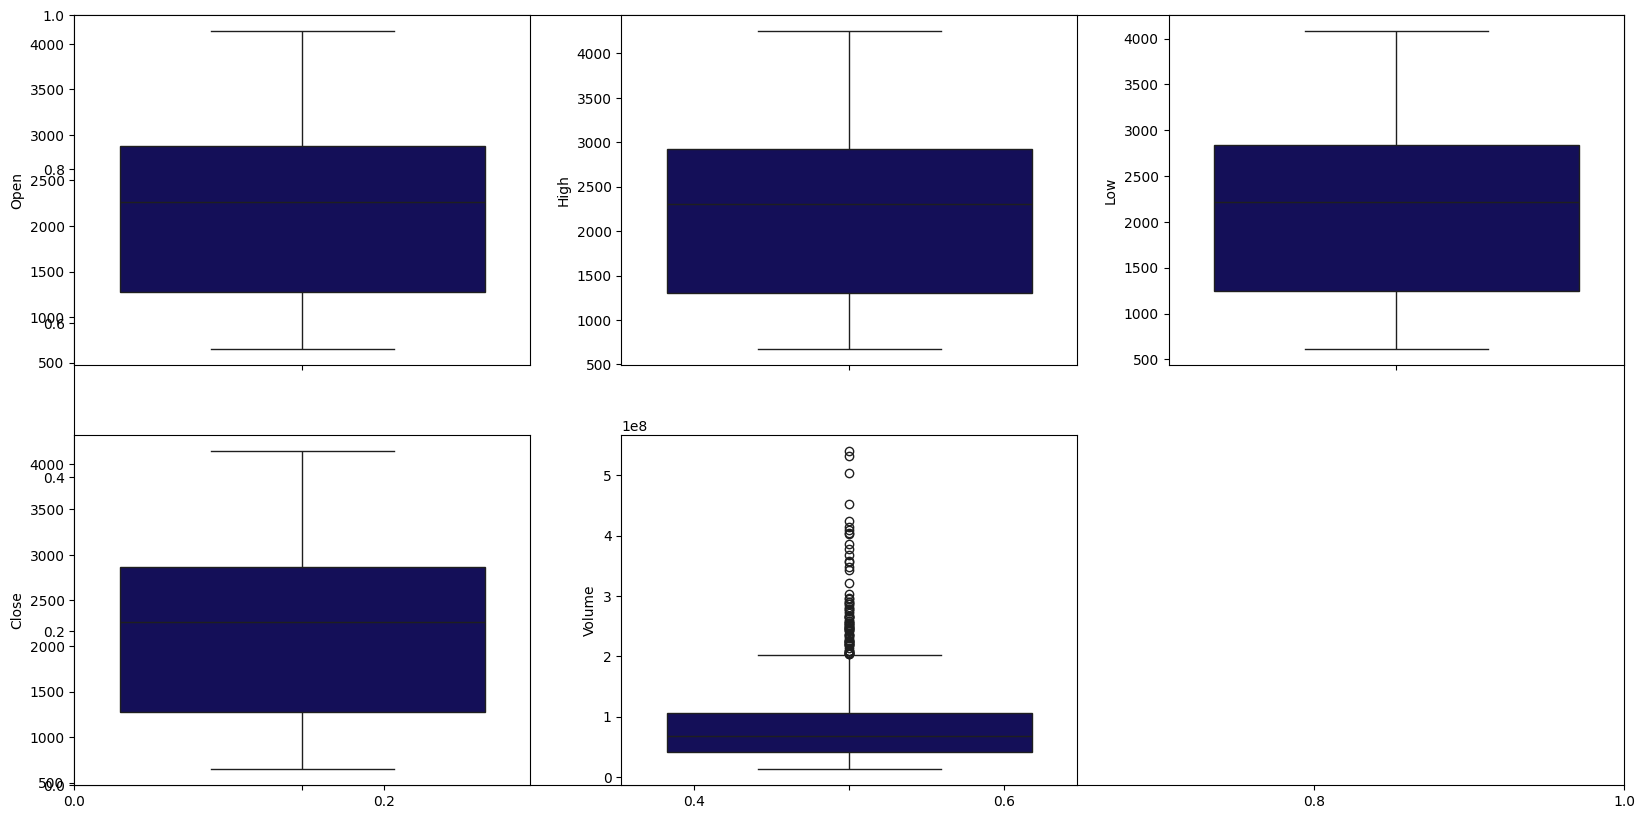

In [87]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
features = ['Open', 'High', 'Low', 'Close', 'Volume']
plt.subplots(figsize=(20,10))
for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sb.boxplot(df[col])
plt.show()

Terlihat hanya kolom Volume yang memiliki outlier. Maka dibutuhkan penanganan terhadap outlier di kolom Volume, Metode Z-score digunakan untuk mendeteksi outlier dalam dataset dengan menghitung Z-score untuk setiap nilai. Z-score mengukur seberapa jauh nilai berada dari rata-rata standar deviasi. Namun sebelum menghitung rumus Z-Score terdapat beberapa nilai yang dibutuhkan yaitu :

1. Simple Moving Average

$$
\text{SMA} = \frac{1}{n} \sum_{i=0}^{n-1} y[i]
$$

Keterangan :
  - $\text{SMA}$: simple moving average.
  - $n$: Ukuran window.
  - $y[i]$: Nilai pada indeks $i$ dalam dataset $y$.

2. Standard Deviation

$$
\text{Standard Deviation} = \sqrt{\frac{1}{n} \sum_{i=0}^{n-1} (y[i] - \text{SMA})^2}
$$

Keterangan :
  - $\text{Standard Deviation}$: Standard deviation.
  - $y[i]$: Nilai pada indeks $i$ dalam dataset $y$.
  - $\text{SMA}$: Simple Moving average.

3. Z-Score

$$
Z_t = \frac{y_t - \text{SMA}}{\text{Standard Deviation}}
$$

Keterangan :
  - $Z_t$: Z-score untuk nilai pada waktu $t$.
  - $y_t$: Nilai pada waktu $t$.
  - $\text{rolling}$: Simple moving average.
  - $\text{Standard Deviation}$: Standard deviation.

4. Indikator outlier

$$
m_t = \begin{cases} 
1 & \text{if } -\text{threshold} \leq Z_t \leq \text{threshold} \\
0 & \text{otherwise}
\end{cases}
$$

Keterangan :
  - $m_t$: Outlier indicator (1 jika bukan outlier, 0 jika outlier).
  - $\text{threshold}$: Ambang batas untuk mendeteksi outlier.

5. Penggantian nilai outlier

$$
\text{Output}_t = \begin{cases} 
y_t & \text{if } m_t = 1 \\
\text{SMA} & \text{if } m_t = 0
\end{cases}
$$

Keterangan :
  - $\text{Output}_t$: Nilai output pada waktu $t$.
  - $y_t$: Nilai asli pada waktu $t$.
  - $\text{SMA}$: Simple moving average dari data.

Dengan kode python sebagai berikut

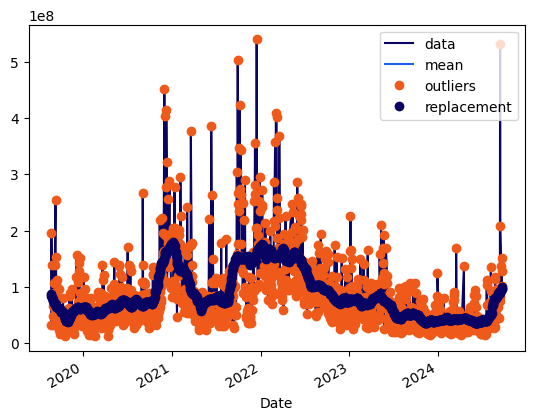

In [88]:
def zscore(s, window, thresh=0, return_all=False):
    roll = s.rolling(window=window, min_periods=1, center=True)
    avg = roll.mean()
    std = roll.std(ddof=0)
    z = s.sub(avg).div(std)   
    m = z.between(-thresh, thresh)
    
    if return_all:
        return z, avg, std, m
    return s.where(m, avg)


z, avg, std, m = zscore(df['Volume'], window=50, return_all=True)

ax = plt.subplot()

df['Volume'].plot(label='data')
avg.plot(label='mean')
df.loc[~m, 'Volume'].plot(label='outliers', marker='o', ls='')
avg[~m].plot(label='replacement', marker='o', ls='')
plt.legend()

Perbandingan sebelum dan sesudah dilakukannya penanganan outlier

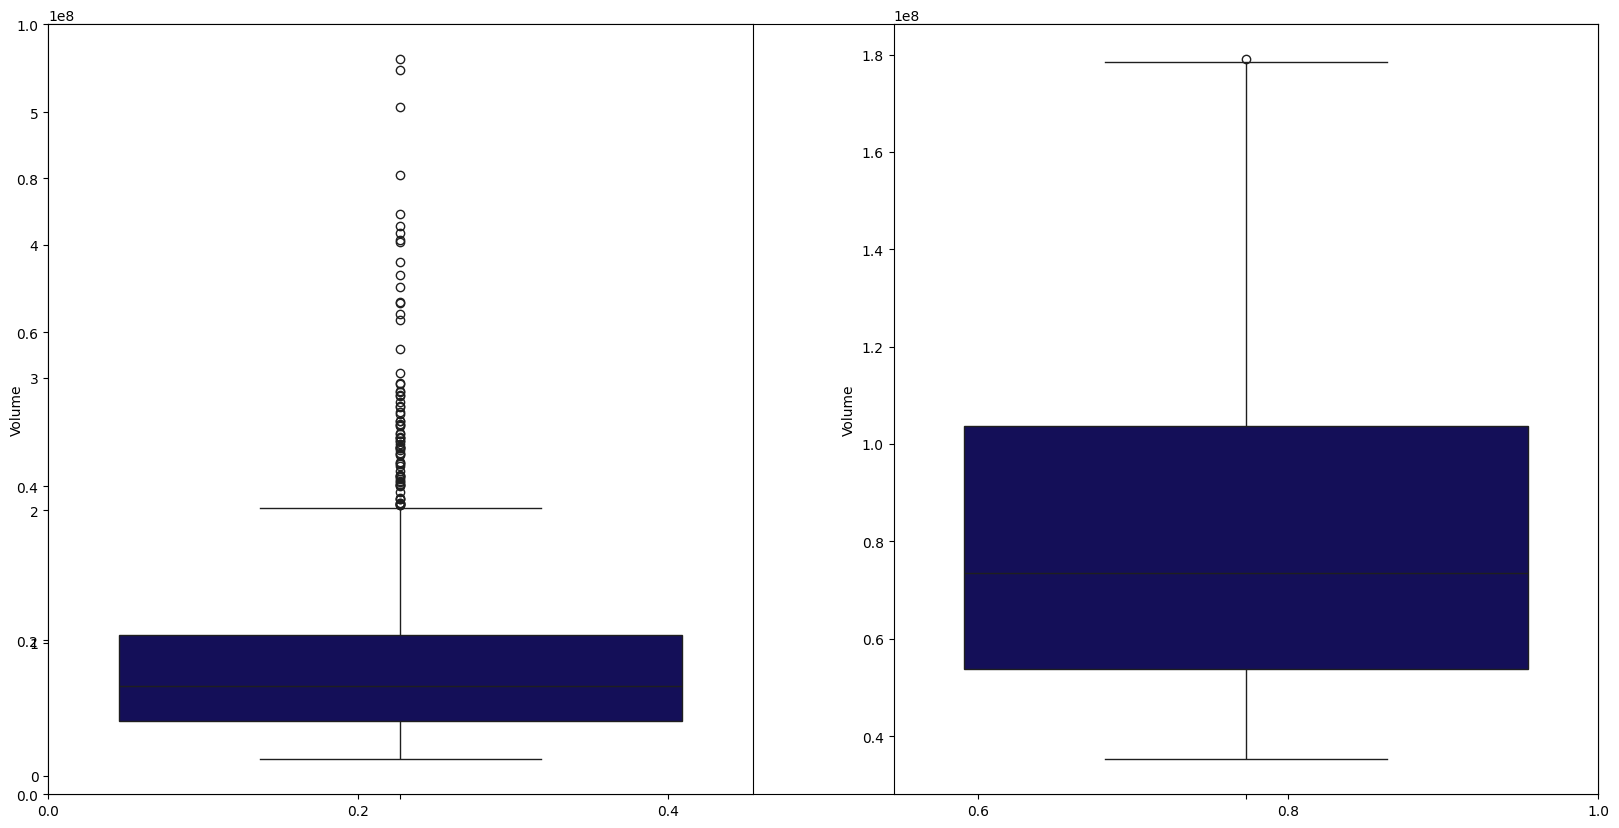

In [89]:
df_temp = zscore(df['Volume'], window=50)
plt.subplots(figsize=(20,10))
plt.subplot(1,2,1)
sb.boxplot(df['Volume'])
plt.subplot(1,2,2)
sb.boxplot(df_temp)
plt.show()

Selanjutnya melihat data trend di masing-masing kolom

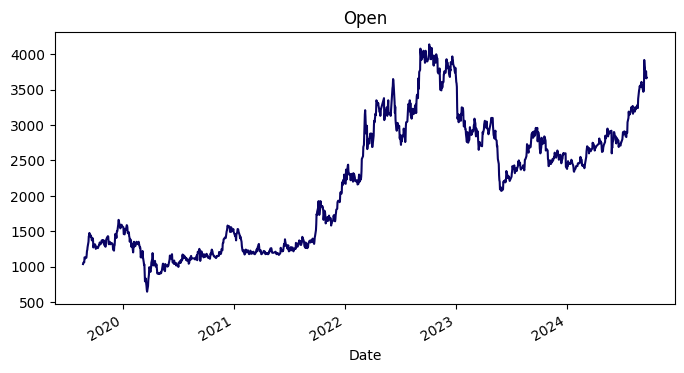

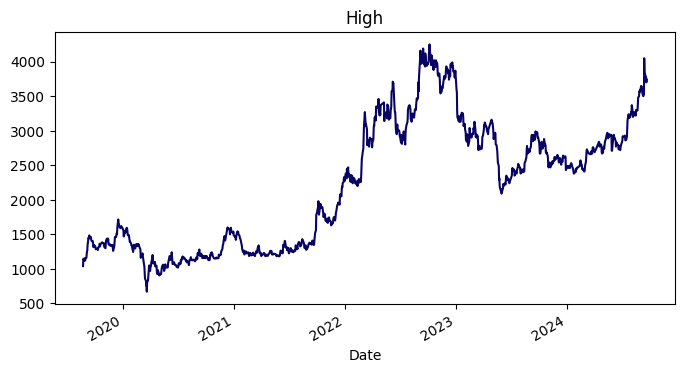

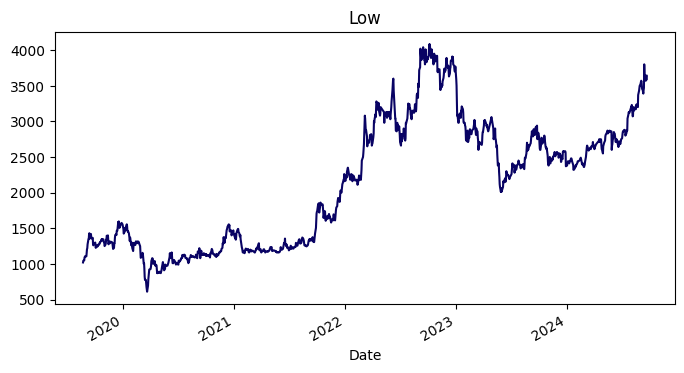

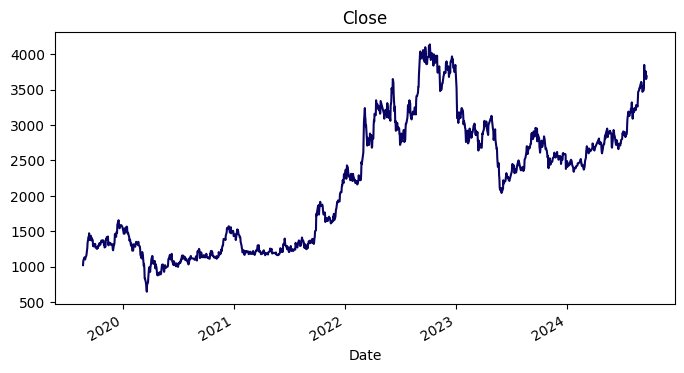

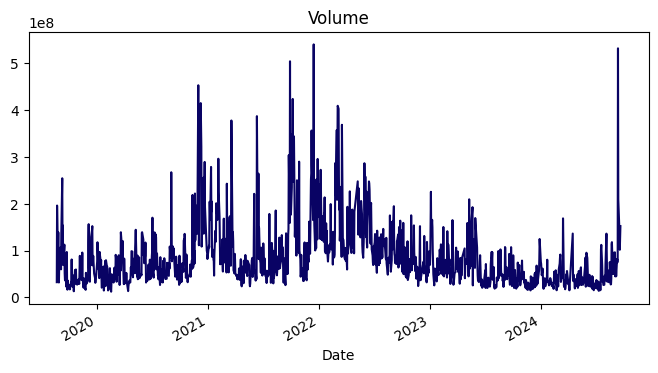

In [90]:
#Data Trend
for i in df:
  df[i].plot(kind='line', figsize=(8, 4), title=i)
  plt.show()

Selanjutnya melihat korelasi antara kolom satu dengan kolom lainnya

<class 'pandas.core.frame.DataFrame'>


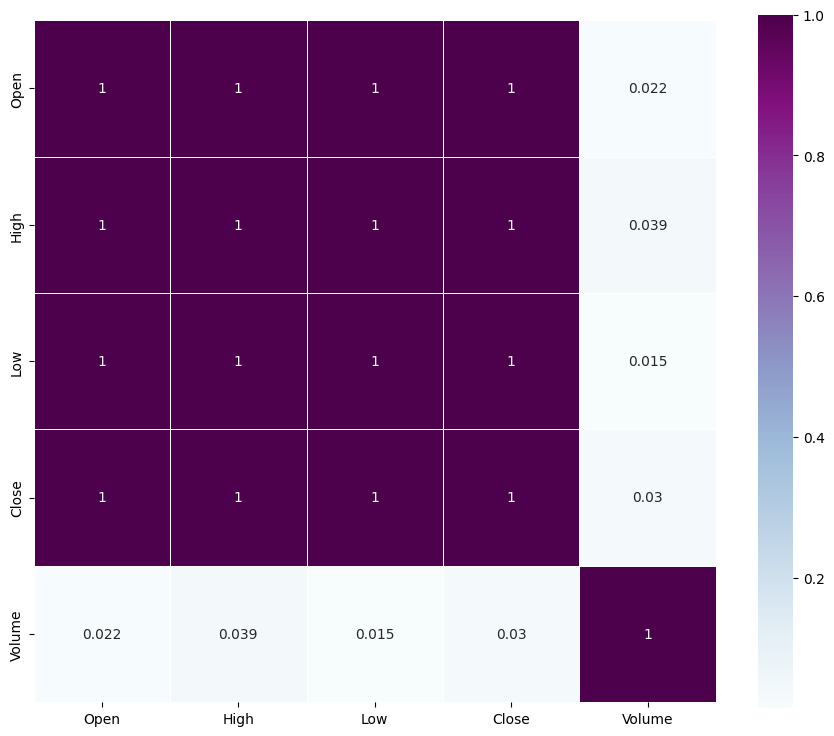

In [91]:
import seaborn as sns
df_corr = df.corr()
print(type(df_corr))

# Menyiapkan gambar matplotlib
f, ax = plt.subplots(figsize=(11, 9))

# Membuat heatmap dengan mask dan proporsi aspek yang benar
sns.heatmap(df_corr, square=True, annot=True, linewidths=0.5, ax=ax, cmap="BuPu")
plt.show()

Terlihat tiap kolom kecuali kolom Volume memiliki nilai korelasi yang sangat tinggi (0.99-1), dapat diartikan bahwa tiap tiap kolom saling berhubungan satu sama lain kecuali kolom volume yang memiliki nilai korelasi negatif dengan kolom lainnya.

#### Verifikasi Kualitas Data

Dapat disimpulkan bahwa data yang digunakan terbilang bagus dan cocok untuk dipakai dalam modelling, namun perlu diperhatikan bahwa data perlu masuk ke tahap preprocessing data agar data benar benar siap untuk masuk ke tahap modelling.

### Pra-pemrosesan Data (Data Preprocessing)

Menggunakan kolom Open, High, Low, Close-1, Volume sebagai fitur input dan fitur target/output yaitu kolom Close. Kolom Volume menggunakan data yang sudah ditangani outliernya.

In [92]:
new_df = df.sort_values(by=['Date']).copy()
new_df['Volume'] = df_temp

Memisahkan dataframe menjadi input dan output

In [93]:
new_df = new_df.dropna()
FEATURES = ['High', 'Low', 'Open', 'Close', 'Volume']

In [94]:
input_df = new_df[FEATURES]

target_df = new_df['Close']

Melakukan scaling menggunakan Min-Max Scaling yaitu mengubah data sehingga semua nilai berada dalam rentang [0, 1] dengan rumus berikut

$$
x' = \frac{x - \text{min}(X)}{\text{max}(X) - \text{min}(X)}
$$

Di mana:

- $x'$ adalah nilai yang dinormalisasi.
- $x$ adalah nilai asli dari fitur.
- $\text{min}(X)$ adalah nilai minimum dari fitur dalam dataset.
- $\text{max}(X)$ adalah nilai maksimum dari fitur dalam dataset.

Min-Max Scaling berguna untuk meningkatkan kinerja LSTM.

In [95]:
from sklearn.preprocessing import RobustScaler, MinMaxScaler

# Convert the data to numpy values
np_data_unscaled = np.array(input_df)

# Transform the data by scaling each feature to a range between 0 and 1
scaler = MinMaxScaler()
np_data_scaled = scaler.fit_transform(np_data_unscaled)

# Creating a separate scaler that works on a single column for scaling predictions
scaler_pred = MinMaxScaler()
df_Close = pd.DataFrame(target_df)
np_Close_scaled = scaler_pred.fit_transform(df_Close)

Selanjutnya mempersiapkan data sebelum masuk ke pemodelan.

In [96]:
sequence_length = 50

Yang berarti model akan melihat 50 hari sebelumnya untuk memprediksi harga di hari berikutnya. Selanjutnya membagi data untuk data train sebesar 80% dan data test sebesar 20% 

In [97]:
import math

# Prediction Index
index_Close = new_df.columns.get_loc("Close")

train_data_len = math.ceil(np_data_scaled.shape[0] * 0.8)

# Create the training and test data
train_data = np_data_scaled[0:train_data_len, :]
test_data = np_data_scaled[train_data_len - sequence_length:, :]

Mempartisi data menjadi input (x) dan target (y).

In [98]:
def partition_dataset(sequence_length, data):
    x, y = [], []
    data_len = data.shape[0]
    for i in range(sequence_length, data_len):
        x.append(data[i-sequence_length:i,:]) #contains sequence_length values 0-sequence_length * columsn
        y.append(data[i, index_Close]) #contains the prediction values for validation,  for single-step prediction
    
    # Convert the x and y to numpy arrays
    x = np.array(x)
    y = np.array(y)
    return x, y

# Generate training data and test data
x_train, y_train = partition_dataset(sequence_length, train_data)
x_test, y_test = partition_dataset(sequence_length, test_data)

# Print the shapes: the result is: (rows, training_sequence, features) (prediction value, )
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

# Validate that the prediction value and the input match up
# The last close price of the second input sample should equal the first prediction value
print(x_train[1][sequence_length-1][index_Close])
print(y_train[0])

(938, 50, 5) (938,)
(246, 50, 5) (246,)
0.19027181688125894
0.19027181688125894


Dengan begitu data sudah siap digunakan modelling.

### Pemodelan Data (Data Modelling)

#### Memilih Model

Menggunakan model LSTM (Long-Short Term Memory) karena diharapkan mampu menangkap pola dalam data time-series, termasuk tren jangka panjang dan fluktuasi harian, sehingga dapat meminimalkan nilai error prediksi yang dihasilkan.

#### Membangun Model

Moenggunakan model Sequential yang terdiri dari lapisan Long Short-Term Memory (LSTM) dengan 200 unit untuk menangkap pola temporal, lapisan Dropout 40% untuk mencegah overfitting, lapisan Dense dengan 100 unit dan aktivasi ReLU untuk hubungan non-linear, serta lapisan Dense dengan 1 unit untuk menghasilkan nilai prediksi.

Menggunakan optimasi Adam serta Callback ModelCheckpoint digunakan untuk menyimpan model pada setiap epoch, sementara EarlyStopping menghentikan pelatihan jika validasi loss tidak membaik selama 5 epoch. Dengan maksimum 30 epoch dan batch size 8, model dilatih menggunakan data validasi untuk memantau performa. Kombinasi elemen ini memastikan model optimal dan tahan terhadap overfitting.


In [99]:
model = Sequential()
model.add(LSTM(200, input_shape=(x_train.shape[1], x_train.shape[2])))  # Satu LSTM layer dengan 200 unit
model.add(Dropout(0.4))  # Dropout untuk mengurangi overfitting
model.add(Dense(100, activation='relu'))  # Dense layer dengan aktivasi ReLU
model.add(Dense(1))  # Layer output untuk prediksi harga

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_squared_error'])
# Menyimpan model pada epoch tertentu
checkpoint = ModelCheckpoint('model_epoch_{epoch:02d}.keras', save_best_only=False, save_weights_only=False, monitor='val_loss', mode='min')
# Menggunakan ModelCheckpoint bersama dengan EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5)

# Melatih model dan menyimpan riwayat pelatihan
history = model.fit(x_train, y_train, epochs=30, batch_size=8, validation_data=(x_test, y_test), callbacks=[checkpoint, early_stopping])


Epoch 1/30


C:\Users\atsuga\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - loss: 0.0247 - mean_squared_error: 0.0247 - val_loss: 0.0011 - val_mean_squared_error: 0.0011
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 0.0033 - mean_squared_error: 0.0033 - val_loss: 6.0179e-04 - val_mean_squared_error: 6.0179e-04
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 0.0022 - mean_squared_error: 0.0022 - val_loss: 0.0022 - val_mean_squared_error: 0.0022
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 0.0025 - mean_squared_error: 0.0025 - val_loss: 7.1250e-04 - val_mean_squared_error: 7.1250e-04
Epoch 5/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 0.0020 - mean_squared_error: 0.0020 - val_loss: 6.5877e-04 - val_mean_squared_error: 6.5877e-04
Epoch 6/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 0.0025 - mean_squared_error: 0.0025 - val_loss: 0.0011 - val_mean_squared_error: 0.0011
Epoch 7/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 0.0025 - mean_squared_error: 0.

#### Menilai Model

Mengevaluasi model yang telah dibuat, menjelaskan kekurangan model, dan hal hal yang perlu diperbaiki untuk model nantinya

### Evaluasi

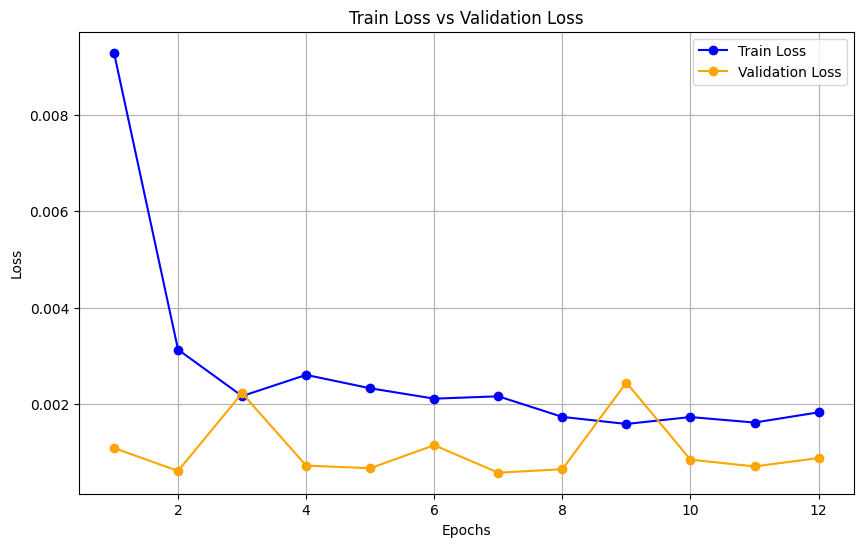

In [100]:
# Mengambil data loss dari history
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)


# Membuat grafik
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, label='Train Loss', marker='o', color='blue')
plt.plot(epochs, val_loss, label='Validation Loss', marker='o', color='orange')
plt.title('Train Loss vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

Terlihat bahwa validation loss tiap epoch naik turun dan tidak ada penurunan yang signifikan sehingga memicu earlystopping dan menghentikan training pada epoch tertentu. Sehingga dipilihlah model terbaik dengan nilai error yang minimal.

In [101]:
from tensorflow.keras.models import load_model

model = load_model('model_epoch_11.keras')


# Get the predicted values
y_pred_scaled = model.predict(x_test)

# Unscale the predicted values
y_pred = scaler_pred.inverse_transform(y_pred_scaled)
y_test_unscaled = scaler_pred.inverse_transform(y_test.reshape(-1, 1))

# Mean Absolute Error (MAE)
MAE = mean_absolute_error(y_test_unscaled, y_pred)
print(f'Median Absolute Error (MAE): {np.round(MAE, 2)}')

# Mean Absolute Percentage Error (MAPE)
MAPE = np.mean((np.abs(np.subtract(y_test_unscaled, y_pred)/ y_test_unscaled))) * 100
print(f'Mean Absolute Percentage Error (MAPE): {np.round(MAPE, 2)} %')

# Median Absolute Percentage Error (MDAPE)
MDAPE = np.median((np.abs(np.subtract(y_test_unscaled, y_pred)/ y_test_unscaled)) ) * 100
print(f'Median Absolute Percentage Error (MDAPE): {np.round(MDAPE, 2)} %')

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step
Median Absolute Error (MAE): 74.27
Mean Absolute Percentage Error (MAPE): 2.73 %
Median Absolute Percentage Error (MDAPE): 2.15 %


Perbandingan data asli dengan data prediksi

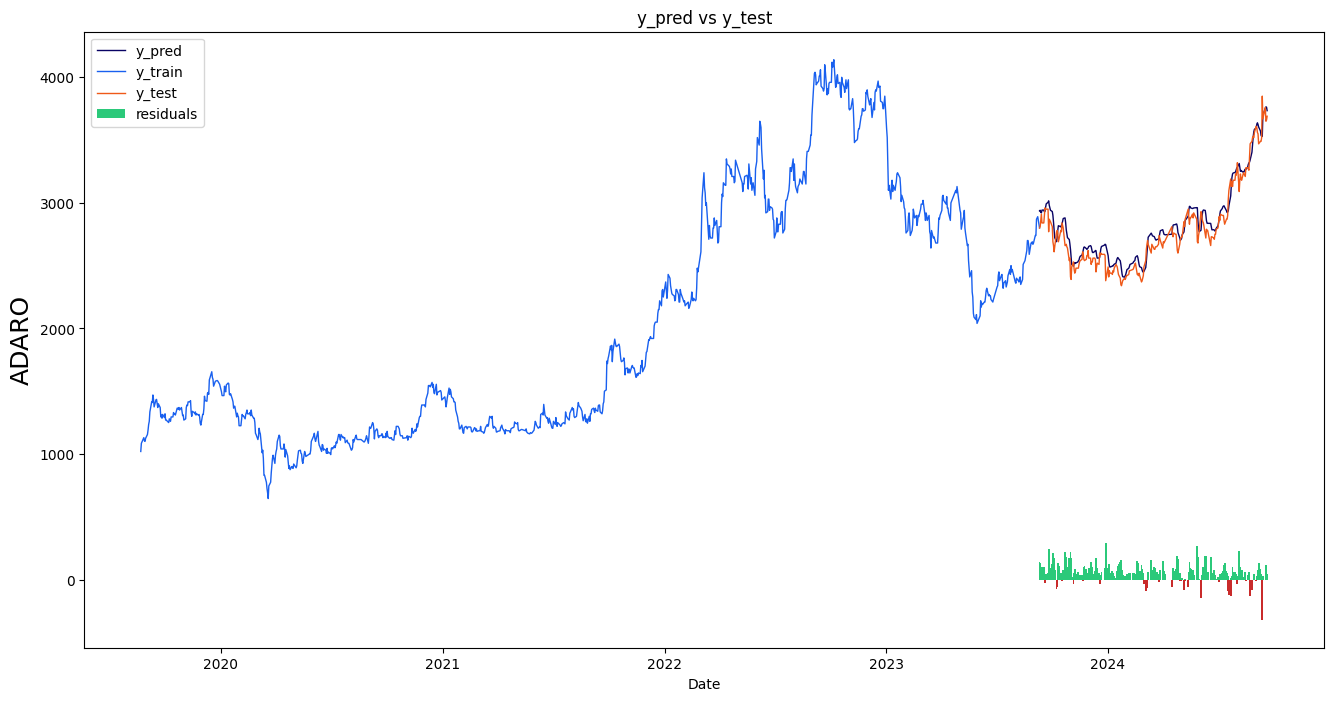

In [102]:
# The date from which on the date is displayed
display_start_date = "2019-01-01" 

# Add the difference between the valid and predicted prices
train = pd.DataFrame(target_df[:train_data_len + 1]).rename(columns={'Close': 'y_train'})
valid = pd.DataFrame(target_df[train_data_len:]).rename(columns={'Close': 'y_test'})
valid.insert(1, "y_pred", y_pred, True)
valid.insert(1, "residuals", valid["y_pred"] - valid["y_test"], True)
df_union = pd.concat([train, valid])

# Zoom in to a closer timeframe
df_union_zoom = df_union[df_union.index > display_start_date]

# Create the lineplot
fig, ax1 = plt.subplots(figsize=(16, 8))
plt.title("y_pred vs y_test")
plt.ylabel(stockname, fontsize=18)
sns.set_palette(["#090364", "#1960EF", "#EF5919"])
sns.lineplot(data=df_union_zoom[['y_pred', 'y_train', 'y_test']], linewidth=1.0, dashes=False, ax=ax1)

# Create the bar plot with the differences
df_sub = ["#2BC97A" if x > 0 else "#C92B2B" for x in df_union_zoom["residuals"].dropna()]
ax1.bar(height=df_union_zoom['residuals'].dropna(), x=df_union_zoom['residuals'].dropna().index, width=3, label='residuals', color=df_sub)
plt.legend()
plt.show()

Uji coba prediksi dengan model yang telah dipilih

In [105]:
df_temp = df[-sequence_length:]
new_df = df_temp.filter(FEATURES)

N = sequence_length

# Get the last N day closing price values and scale the data to be values between 0 and 1
last_N_days = input_df[-sequence_length:].values
#print(last_N_days)
last_N_days_scaled = scaler.transform(last_N_days)

# Create an empty list and Append past N days
X_test_new = []
X_test_new.append(last_N_days_scaled)

# Convert the X_test data set to a numpy array and reshape the data
pred_price_scaled = model.predict(np.array(X_test_new))
pred_price_unscaled = scaler_pred.inverse_transform(pred_price_scaled.reshape(-1, 1))

# Print last price and predicted price for the next day
price_today = np.round(new_df['Close'][-1], 2)
predicted_price = np.round(pred_price_unscaled.ravel()[0], 2)
change_percent = np.round(100 - (price_today * 100)/predicted_price, 2)

plus = '+'; minus = ''
print(f'The predicted close price is {predicted_price} ({plus if change_percent > 0 else minus}{change_percent}%)')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
The predicted close price is 3724.06005859375 (+0.91%)


C:\Users\atsuga\AppData\Local\Temp\ipykernel_12132\4251102145.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  price_today = np.round(new_df['Close'][-1], 2)


### Deployment

Project dideploy ke situs huggingface